In [10]:
import pandas as pd
import numpy as np

# -----------------------------
# Load and basic cleaning
# -----------------------------
dfs = [pd.read_parquet(f"../data/checkpoints/checkpoints/01_cleaned_data/01_cleaned_data_part_{i}.parquet") for i in range(1,21)]
df = pd.concat(dfs, ignore_index=True)

df = df.drop(columns=["issn", "isbn"], errors="ignore")
df = df.dropna(subset=["id", "references"]).copy()

# Keep references as clean, non-empty string lists
def clean_references(x):
    if isinstance(x, (list, np.ndarray)):
        out = [r for r in x if r is not None and str(r).strip() != ""]
        return out
    return []

df["references"] = df["references"].apply(clean_references)
df = df[df["references"].map(len) > 0].reset_index(drop=True)

# Helper function: check whether a value is empty
def is_not_empty(x):
    if isinstance(x, (list, np.ndarray)):
        return len(x) > 0
    elif pd.isna(x):
        return False
    else:
        return len(str(x).strip()) > 0

# Apply to all rows without using applymap
mask = df.apply(lambda row: all(is_not_empty(v) for v in row), axis=1)

# Keep only fully populated rows
df = df[mask].reset_index(drop=True)

print("Righe dopo rimozione valori vuoti:", len(df))

# -----------------------------
# Build positive pairs
# -----------------------------
pairs = df[["id", "references"]].explode("references")
pairs = pairs.rename(columns={"id": "article_id", "references": "ref_id"})
pairs = pairs.dropna(subset=["ref_id"])
pairs = pairs[pairs["ref_id"].astype(str).str.strip() != ""].reset_index(drop=True)

# Filter references that exist in the dataset
ref_ids_in_dataset = set(df["id"].values)
pairs = pairs[pairs["ref_id"].isin(ref_ids_in_dataset)].reset_index(drop=True)

# Article and reference feature tables
article_features = df.drop(columns=["references"]).add_suffix("_article")
article_features = article_features.rename(columns={"id_article": "article_id"})

ref_features = df.drop(columns=["references"]).add_suffix("_ref")
ref_features = ref_features.rename(columns={"id_ref": "ref_id"})

# Positive samples: (article_id, real ref_id)
df_pos = (
    pairs
    .merge(article_features, on="article_id", how="left")
    .merge(ref_features, on="ref_id", how="inner")
)
df_pos["is_reference_valid"] = 1

print("Positive samples:", len(df_pos))

# -----------------------------
# Build fake negative references
# -----------------------------
all_ids = df["id"].to_numpy()
true_refs_by_article = df.set_index("id")["references"].apply(set).to_dict()

fake_ref_ids = []
for article_id in pairs["article_id"].to_numpy():
    true_refs = true_refs_by_article.get(article_id, set())

    # Draw a random reference that is not a true reference for this article
    fake = np.random.choice(all_ids)
    while fake in true_refs:
        fake = np.random.choice(all_ids)
    fake_ref_ids.append(fake)

neg_pairs = pairs[["article_id"]].copy()
neg_pairs["ref_id"] = fake_ref_ids

# Negative samples: (article_id, fake ref_id)
df_neg = (
    neg_pairs
    .merge(article_features, on="article_id", how="left")
    .merge(ref_features, on="ref_id", how="inner")
)
df_neg["is_reference_valid"] = 0

print("Negative samples:", len(df_neg))

# -----------------------------
# Final training dataset
# -----------------------------
df_training = pd.concat([df_pos, df_neg], ignore_index=True)
df_training = df_training.dropna().sort_values("year_article").reset_index(drop=True)


df_training.dropna(inplace=True)
df_training.sort_values('year_article', inplace=True)

df_training = df_training[df_training["year_article"] >= df_training['year_ref']].reset_index(drop=True)

print("Final training dataset:", len(df_training))

Righe dopo rimozione valori vuoti: 393557
Positive samples: 811245
Negative samples: 811245
Final training dataset: 1301193


In [8]:
X = df_training.drop(columns=['is_reference_valid', 'article_id', 'ref_id']).copy()
y = df_training['is_reference_valid'].copy()

def extract_author_names(authors):
    if isinstance(authors, dict):
        return authors.get('name', '')
    if isinstance(authors, list):
        return ', '.join(a.get('name', '') for a in authors)
    return ''

# Testo articolo e riferimento
X['vector_text_article'] = X.apply(
    lambda row: f"{row.get('title_article', '')} {row.get('abstract_article', '')} {row.get('keywords_article', '')} {extract_author_names(row.get('authors_article', ''))}",
    axis=1
)
X['vector_text_ref'] = X.apply(
    lambda row: f"{row.get('title_ref', '')} {row.get('abstract_ref', '')} {row.get('keywords_ref', '')} {extract_author_names(row.get('authors_ref', ''))}",
    axis=1
)

X['vector_text_article'] = X['vector_text_article'].fillna('').astype(str)
X['vector_text_ref'] = X['vector_text_ref'].fillna('').astype(str)

In [9]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from feature_extractor import FeatureExtractor

feature_extractor = FeatureExtractor(max_features=256)

articles = X['vector_text_article'].tolist()
refs = X['vector_text_ref'].tolist()

feature_extractor.fit(articles, refs)
res = feature_extractor.transform(articles, refs)

X_articles, X_refs, sims = res


# Mantieni solo metadati convertibili a numerico
drop_non_numeric_cols = [
    'title_article', 'abstract_article', 'keywords_article', 'lang_article',
    'authors_article', 'venue_article', 'doc_type_article', 'doi_article', 'url_article',
    'title_ref', 'abstract_ref', 'keywords_ref', 'lang_ref',
    'authors_ref', 'venue_ref', 'doc_type_ref', 'doi_ref', 'url_ref',
    'vector_text_article', 'vector_text_ref'
]

meta = X.drop(columns=drop_non_numeric_cols, errors='ignore').copy()
for col in meta.columns:
    meta[col] = pd.to_numeric(meta[col], errors='coerce').fillna(0.0)

if meta.shape[1] > 0:
    X_meta = sp.csr_matrix(meta.to_numpy(dtype=np.float32))
else:
    X_meta = sp.csr_matrix((len(X), 0), dtype=np.float32)

sims_col = sp.csr_matrix(np.asarray(sims, dtype=np.float32).reshape(-1, 1))
X_model = sp.hstack([X_meta, X_articles.tocsr(), X_refs.tocsr(), sims_col], format='csr')
y_model = y.to_numpy()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (10477, 20013) Test: (2620, 20013)


              precision    recall  f1-score   support

           0     0.9047    0.7513    0.8209       973
           1     0.8664    0.9532    0.9078      1647

    accuracy                         0.8782      2620
   macro avg     0.8856    0.8523    0.8643      2620
weighted avg     0.8807    0.8782    0.8755      2620



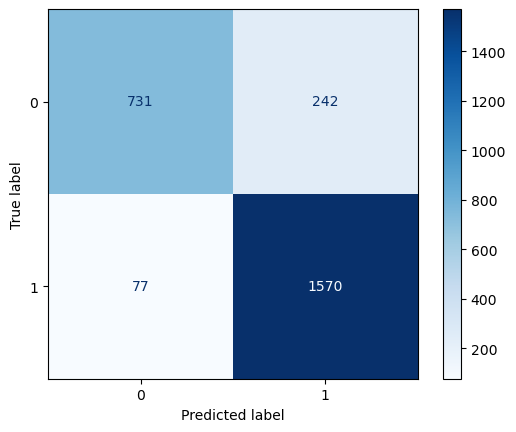

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rnd_clf.fit(X_train, y_train)

y_pred = rnd_clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.classes_)
disp.plot(cmap='Blues')